In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#__Laboratorio. Aprendizaje no supervisado__

## __K-means__

Aplique el algoritmo de k-means a los cuatro conjuntos de datos que se presentan a continuación. Determine la cantidad óptima de grupos en cada caso.

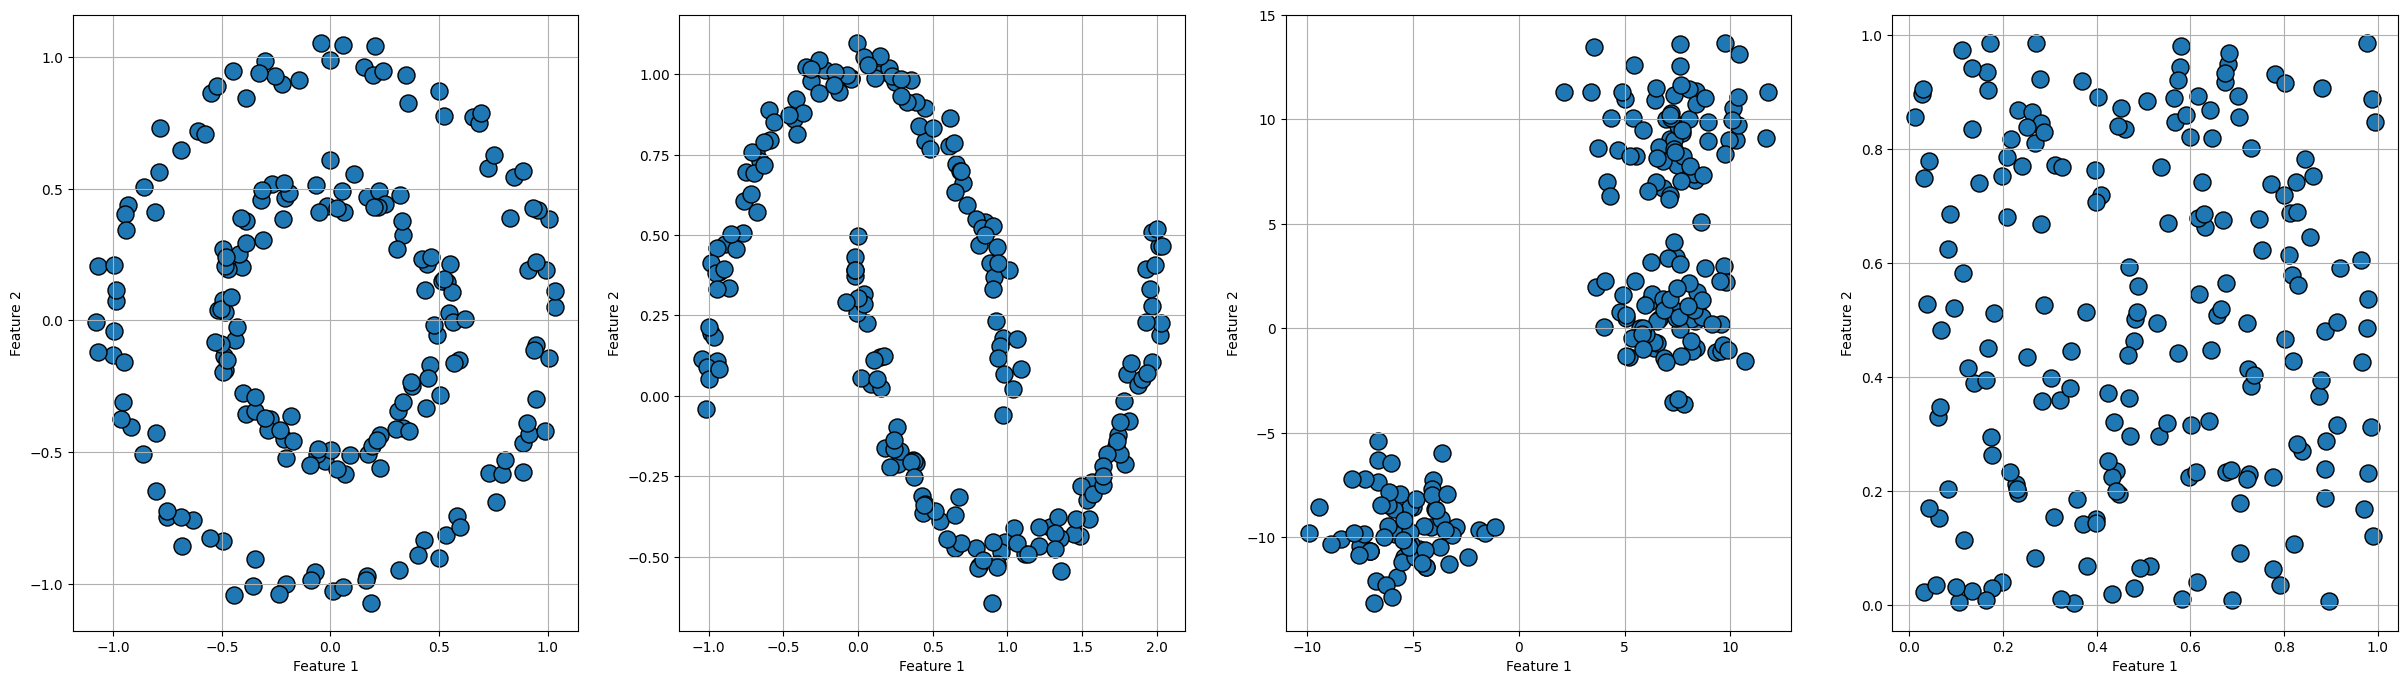

In [ ]:
from sklearn import cluster, datasets
import numpy as np
import matplotlib.pyplot as plt

n_samples = 200
noisy_circles, _ = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons, _ = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs, _ = datasets.make_blobs(n_samples=n_samples, cluster_std=1.7, random_state=8)
no_structure, _ = np.random.rand(n_samples, 2), None

dataset = [noisy_circles, noisy_moons, blobs, no_structure]

fig, axes = plt.subplots(1, 4, figsize=(30, 8))

for index, data in enumerate(dataset):
  axes[index].scatter(data[:, 0], data[:, 1], marker='o',  edgecolor='black', s=150)
  axes[index].set_xlabel('Feature 1')
  axes[index].set_ylabel('Feature 2')
  axes[index].grid()
plt.show()


## __Agrupando imagenes__
Utilice el algoritmo de k-means para intentar agrupar las imágenes por
individuos. Experimente con diferente número de grupos y visualice los valores de las clases así como los centroides. ¿Qué se puede concluir a partir de los resultados?. La información completa de conjunto de datos disponible en [fetch_olivetti_faces](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html)

In [ ]:
from sklearn.datasets import fetch_olivetti_faces

olivetti_faces = fetch_olivetti_faces()
olivetti_faces.images.shape

(400, 64, 64)

(64, 64) 0.7231405


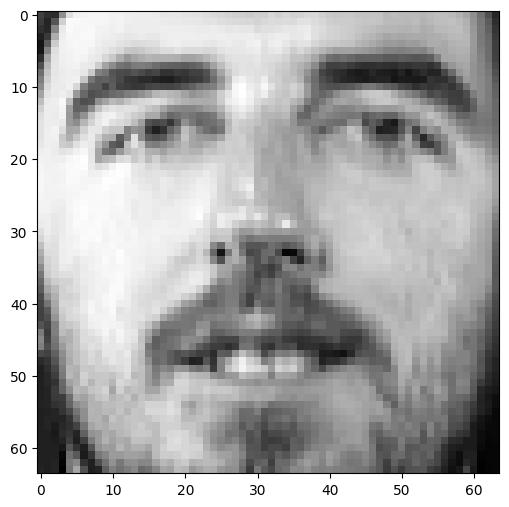

In [ ]:
image = olivetti_faces.images[100]
print(image.shape, image[0, 31])
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')

In [ ]:
print(image)

[[0.45454547 0.47107437 0.5123967  ... 0.19008264 0.18595041 0.18595041]
 [0.446281   0.48347107 0.5206612  ... 0.21487603 0.2107438  0.2107438 ]
 [0.49586776 0.5165289  0.53305787 ... 0.20247933 0.20661157 0.20661157]
 ...
 [0.77272725 0.78099173 0.7933884  ... 0.1446281  0.1446281  0.1446281 ]
 [0.77272725 0.7768595  0.7892562  ... 0.13636364 0.13636364 0.13636364]
 [0.7644628  0.7892562  0.78099173 ... 0.15289256 0.15289256 0.15289256]]


In [ ]:
image.flatten().shape

(4096,)

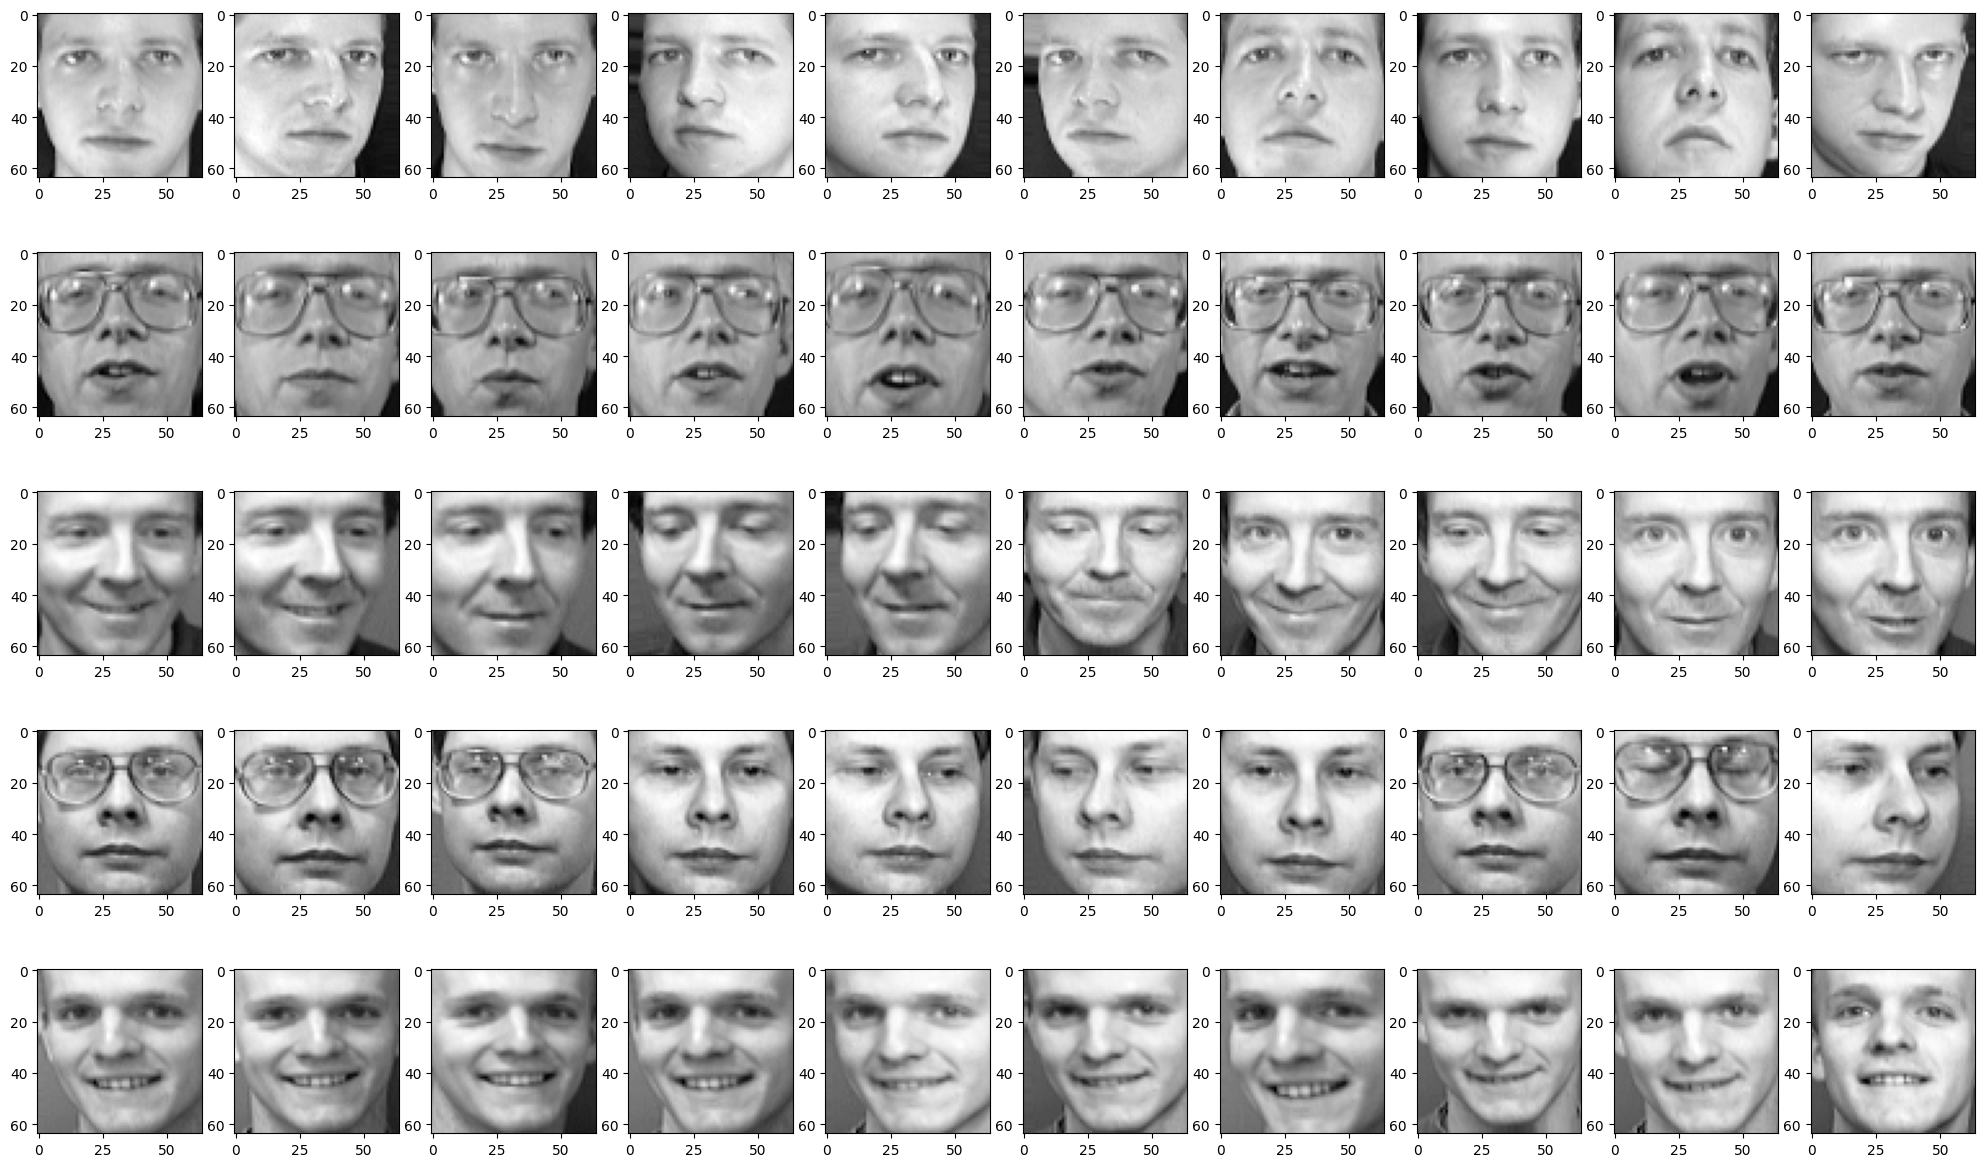

In [ ]:
rows = 5
columns = 10
fig, axes = plt.subplots(rows, columns, figsize=(25, 15))
index = 0
for i in range(rows):
  for j in range(columns):
    axes[i][j].imshow(olivetti_faces.images[index], 'gray')
    index += 1

In [ ]:
faces = pd.DataFrame(olivetti_faces.data)
faces['target'] = olivetti_faces.target
faces.head(20)

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0
5,0.549587,0.545455,0.541322,0.537190,0.537190,0.533058,0.528926,0.533058,0.590909,0.611570,...,0.619835,0.623967,0.615702,0.661157,0.661157,0.690083,0.714876,0.706612,0.702479,0
6,0.330579,0.305785,0.330579,0.351240,0.425620,0.500000,0.603306,0.632231,0.644628,0.644628,...,0.541322,0.541322,0.524793,0.537190,0.487603,0.190083,0.144628,0.152893,0.152893,0
7,0.128099,0.185950,0.247934,0.314050,0.388430,0.462810,0.520661,0.557851,0.590909,0.623967,...,0.157025,0.165289,0.148760,0.157025,0.157025,0.152893,0.152893,0.173554,0.173554,0
8,0.243802,0.297521,0.367769,0.454545,0.495868,0.537190,0.578512,0.603306,0.611570,0.632231,...,0.669421,0.537190,0.235537,0.169421,0.177686,0.190083,0.190083,0.181818,0.190083,0
9,0.380165,0.442149,0.483471,0.545455,0.582645,0.628099,0.648760,0.677686,0.690083,0.710744,...,0.157025,0.165289,0.148760,0.165289,0.173554,0.173554,0.173554,0.173554,0.173554,0


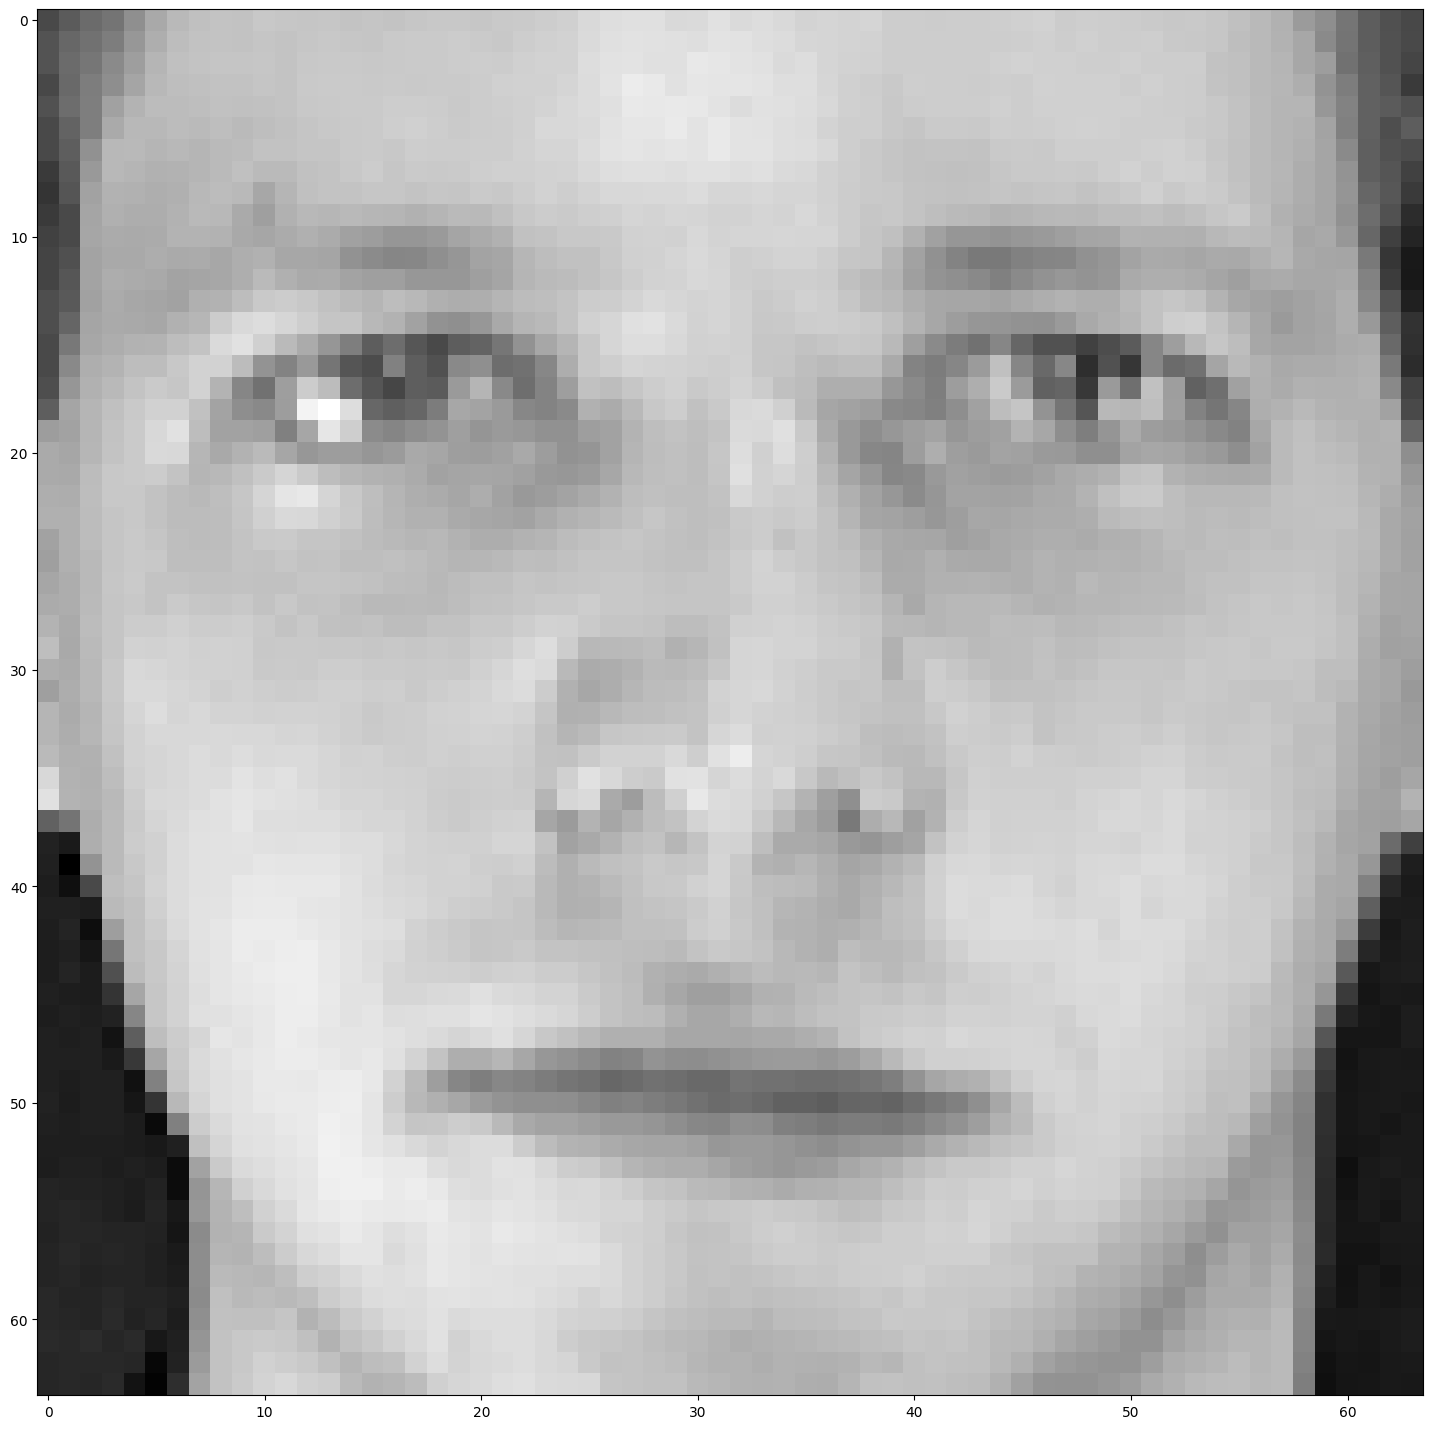

In [ ]:
plt.figure(figsize=(18,18))
image2 = olivetti_faces.data[0].reshape(64, 64)
plt.imshow(image2, 'gray')